In [2]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import muspan as ms
from itertools import zip_longest
from typing import List, Tuple, Optional
import math
from functools import partial
import seaborn as sns
from scipy import stats
import pathlib

In [ ]:
# unordered_met_nos = [2,2,1,1,3,17,4,23,7,13]
# unordered_domains_order = ['AKPT_Liver_Mets_4d_1_Region_1', 
#            'AKPT_Liver_Mets_4d_1_Region_2', 
#            'AKPT_Liver_Mets_4d_2_Region_1', 
#            'AKPT_Liver_Mets_4d_3_Region_1', 
#            'AKPT_Liver_Mets_4d_5_Region_1', 
#            'AKPT_Liver_Mets_28d_1_Region_1',
#            'AKPT_Liver_Mets_28d_1_Region_2',
#            'AKPT_Liver_Mets_28d_2_Region_1',
#            'AKPT_Liver_Mets_28d_2_Region_2',
#            'AKPT_Liver_Mets_28d_3_Region_1']

In [7]:
directory = pathlib.Path("../outputs/In_out")
i=0
list_of_files = []
for item in directory.rglob("*"):
    if item.is_file():
            if str(item) != str(directory)+'/.DS_Store':
                list_of_files.append(str(item))
            i+=1
names = [x.replace('../domains_with_mets/', '').replace('.muspan', '') for x in list_of_files]

In [8]:
print(names)

['../outputs/In_out/Sample_4d_5', '../outputs/In_out/Sample_4d_1_2', '../outputs/In_out/Sample_28d_2_2', '../outputs/In_out/Sample_4d_3', '../outputs/In_out/Sample_28d_2', '../outputs/In_out/Sample_4d_1', '../outputs/In_out/Sample_28d_1', '../outputs/In_out/Sample_4d_2', '../outputs/In_out/Sample_28d_3', '../outputs/In_out/Sample_28d_1_2']


In [9]:
met_nos = [1,1,2,3,7,17,2,23,13,4]
domains_order = ['AKPT_Liver_Mets_4d_2_Region_1', 
                'AKPT_Liver_Mets_4d_3_Region_1', 
                'AKPT_Liver_Mets_4d_1_Region_2', 
                'AKPT_Liver_Mets_4d_5_Region_1',
                'AKPT_Liver_Mets_28d_2_Region_2', 
                'AKPT_Liver_Mets_28d_1_Region_1', 
                'AKPT_Liver_Mets_4d_1_Region_1',
                'AKPT_Liver_Mets_28d_2_Region_1',
                'AKPT_Liver_Mets_28d_3_Region_1',
                'AKPT_Liver_Mets_28d_1_Region_2']
# AKPT_Liver_Mets_4d_4_Region_1

In [12]:
list_of_domains = []
for i in range(len(list_of_files)):
    list_of_domains.append(ms.io.load_domain(list_of_files[i], print_summary=False))

In [11]:
pc = ms.io.load_domain(list_of_files[0], print_summary=True)

MuSpAn domain loaded successfully. Domain summary:
Domain name: AKPT_Liver_Mets_4d_5_Region_1
Number of objects: 83958
Collections: ['Cell boundaries', 'Met annotations', 'Cell centres', 'Detailed Met Annotations', 'Cell Boundaries in Met 1', 'Cell Centres in Met 1', 'Metastasis 1', 'Cell Boundaries in Met 2', 'Cell Centres in Met 2', 'Metastasis 2', 'Cell Boundaries in Met 3', 'Cell Centres in Met 3', 'Metastasis 3']
Labels: ['Cell ID', 'Transcript Counts', 'Cell Area', 'Cluster ID', 'Nucleus Area', 'Transcript Counts: 1700019D03Rik', 'Transcript Counts: Abcc8', 'Transcript Counts: Acta2', 'Transcript Counts: Acvr1b', 'Transcript Counts: Acvr2a', 'Transcript Counts: Adgra2', 'Transcript Counts: Adgre1', 'Transcript Counts: Adh1', 'Transcript Counts: Adra2a', 'Transcript Counts: Afap1l2', 'Transcript Counts: Alb', 'Transcript Counts: Alcam', 'Transcript Counts: Aldh1b1', 'Transcript Counts: Aldoa', 'Transcript Counts: Amotl2', 'Transcript Counts: Ano7', 'Transcript Counts: Anxa1', 'Tra

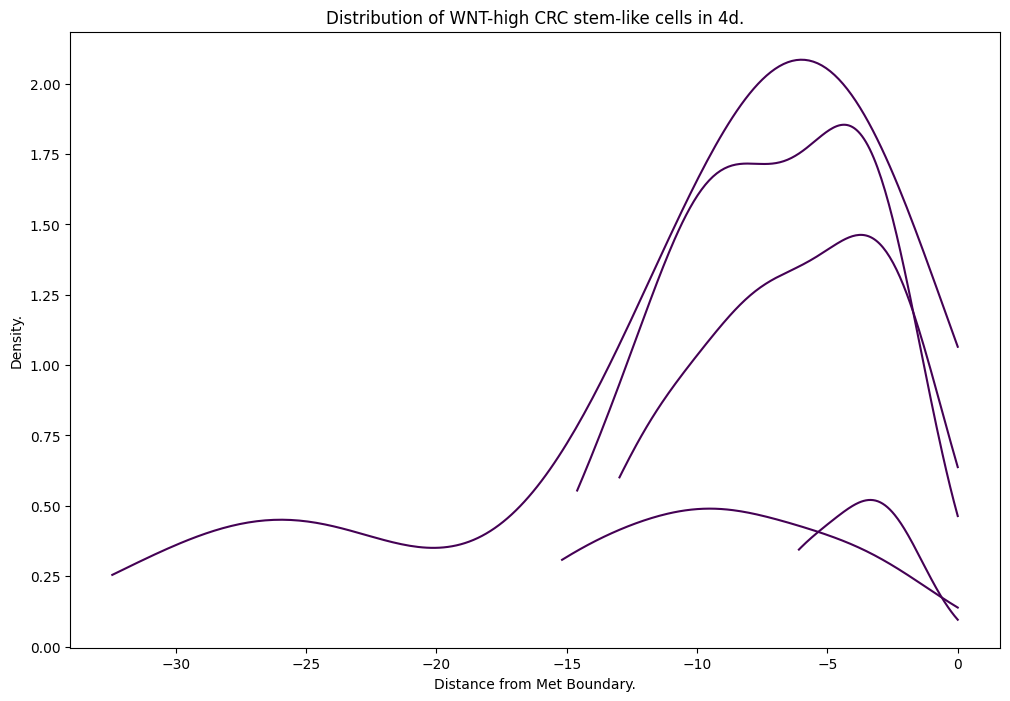

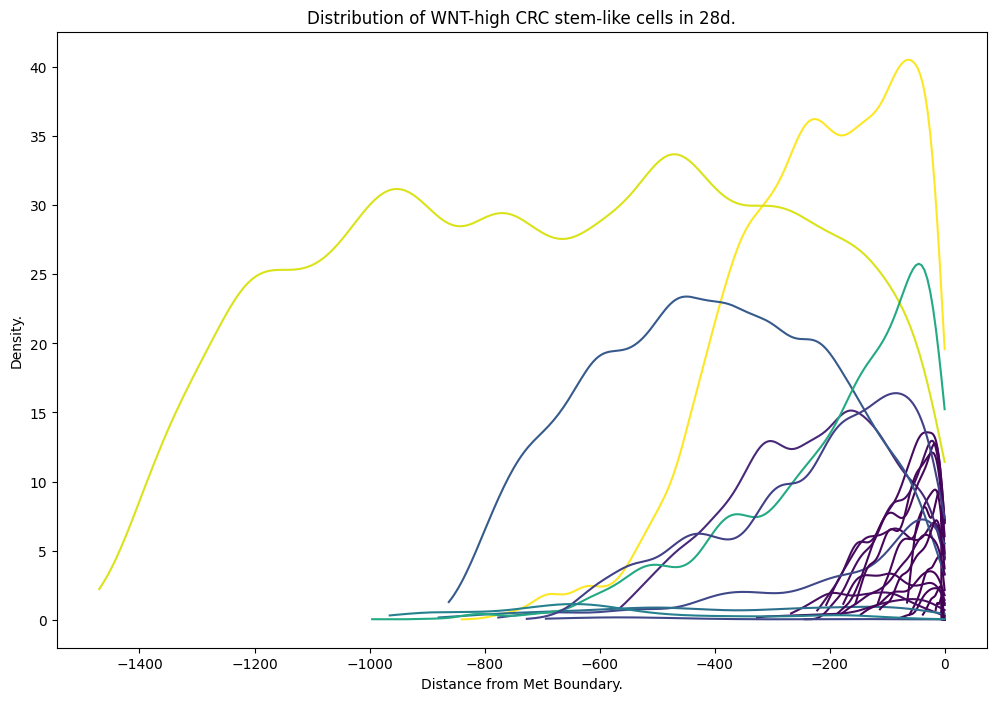

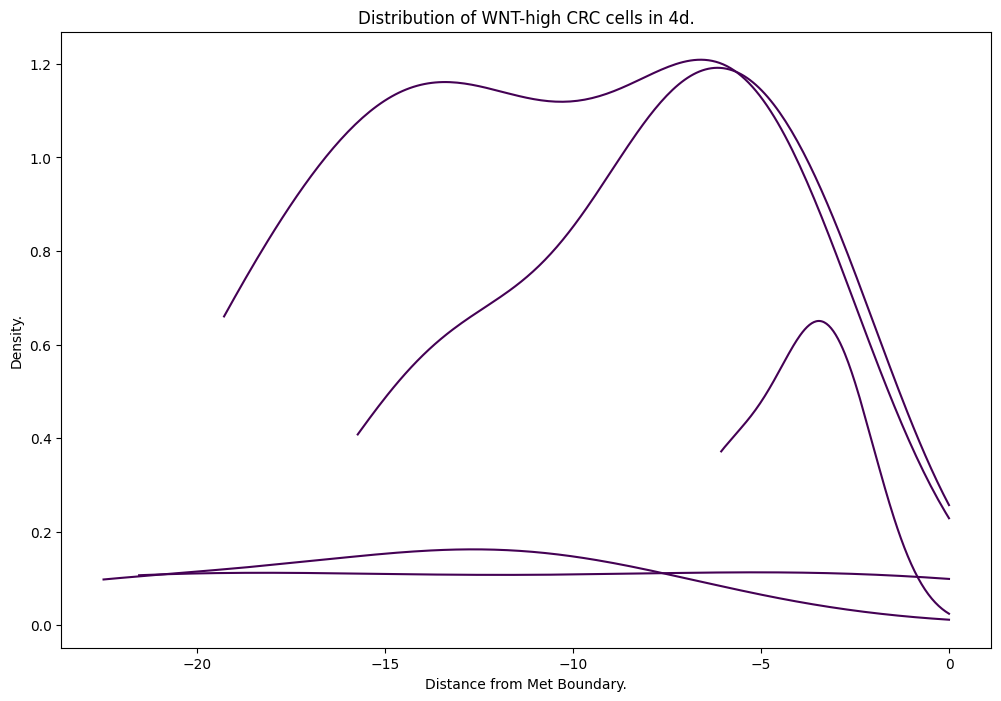

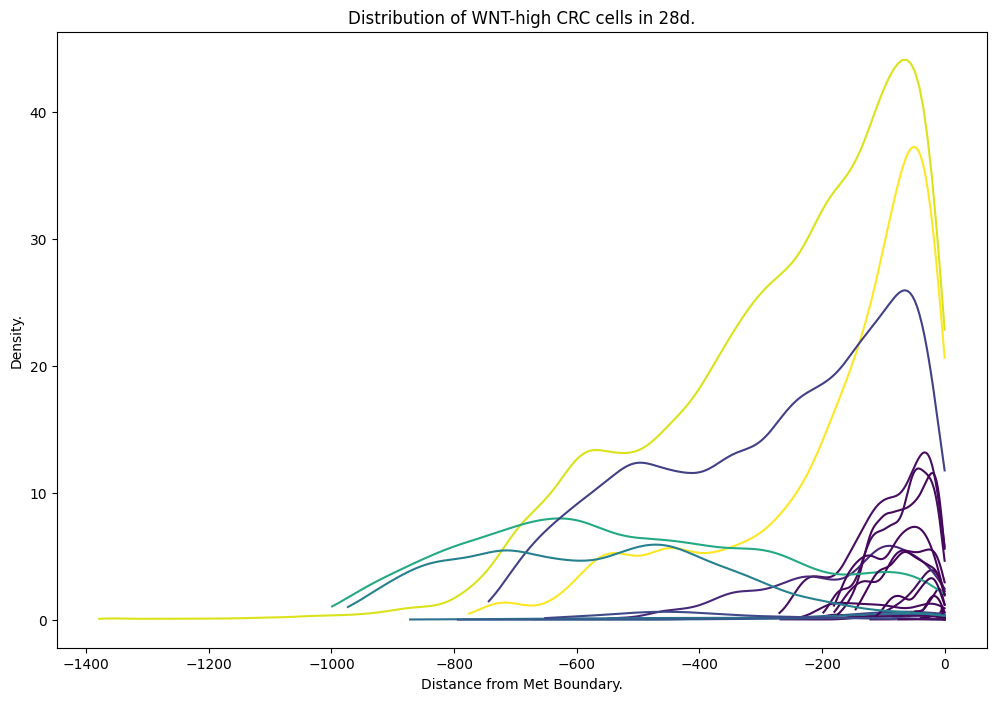

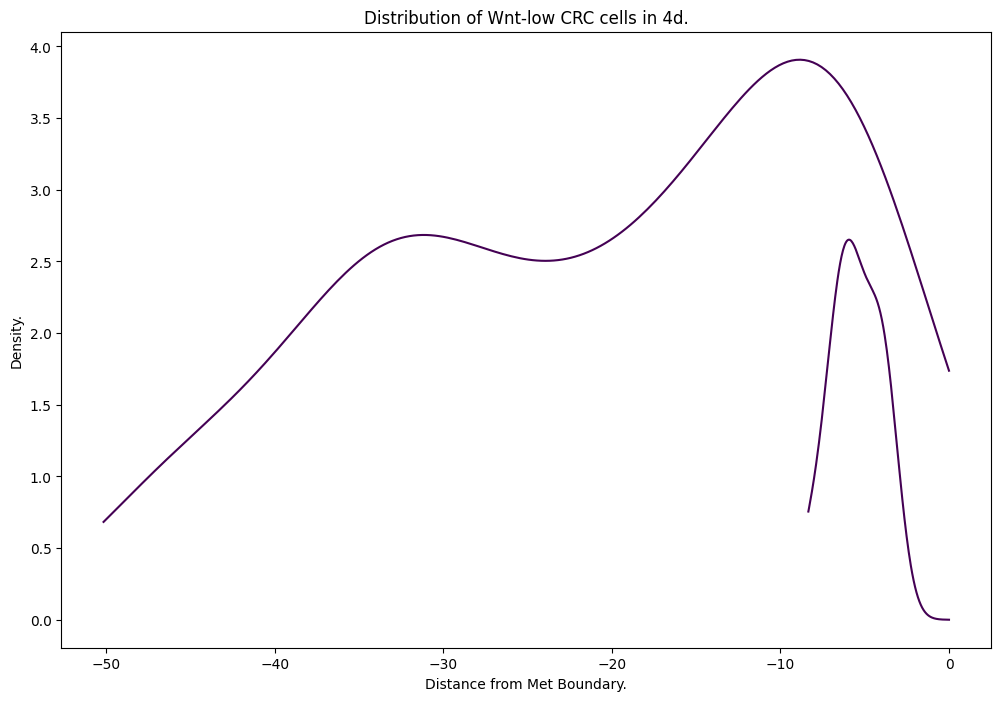

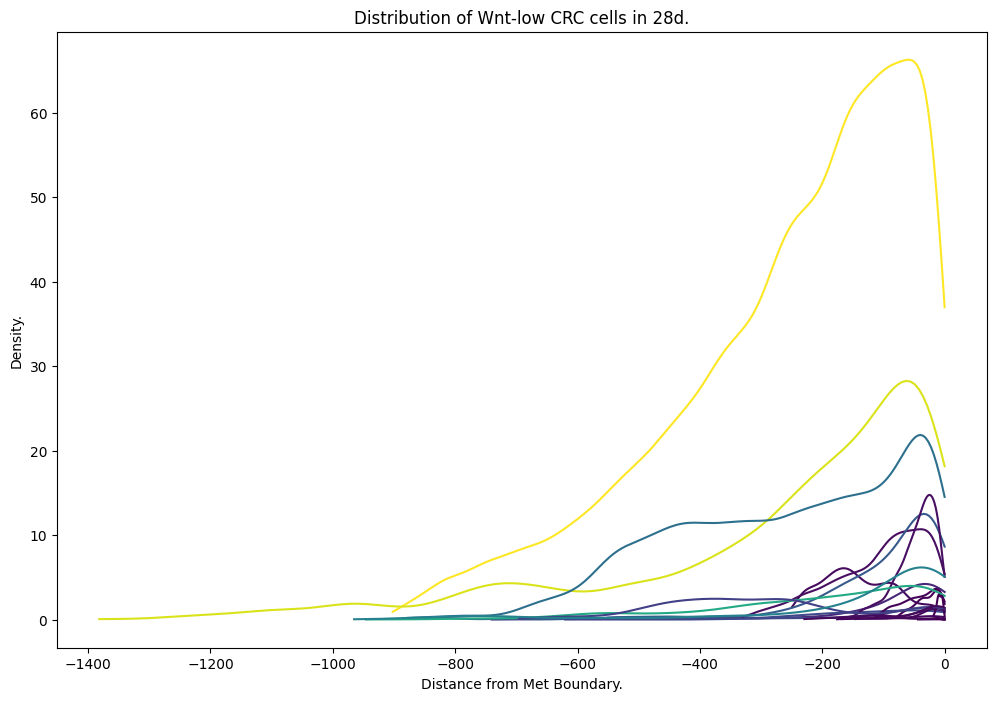

In [18]:
# specify cell type of interest
celltypes = ['WNT-high CRC stem-like cells', 'WNT-high CRC cells', 'Wnt-low CRC cells']
label_name = 'Detailed celltype (liver)'

colours = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000', '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#000000']
list_of_axes = []
list_of_figs = []
list_of_max_met_dists = []
list_of_max_out_dists = []
all_met_distances = []
all_out_distances = []
all_regional_max_met_dists = []
for dom in range(len(list_of_domains)):
    domain = list_of_domains[dom]
    met_no = met_nos[domains_order.index(str(domain.name))]
    one_domain_met_distances = []
    one_domain_out_distances = []
    for region_no in range(met_no):
        met_distances = np.load('../outputs/Useful_Data/'+str(domain.name)+'_inside_Met_'+str(region_no+1)+'.npy', allow_pickle=True)
        one_domain_met_distances.append(met_distances)
    out_distances = np.load('../outputs/Useful_Data/'+str(domain.name)+'_outside_to_all_Mets.npy', allow_pickle=True)
    # one_domain_out_distances.append(out_distances)
    all_out_distances.append(out_distances)
    all_met_distances.append(one_domain_met_distances)

for dom in range(6):
    # figures
    fig, axes = plt.subplots(1, 1, figsize=(12, 8))
    ages = ['4d', '28d']
    if (dom == 0) or (dom == 1):
        axes.set_title('Distribution of ' + str(celltypes[0]) + ' in ' + str(ages[dom]) + '.')
    elif (dom == 2) or (dom == 3):
        axes.set_title('Distribution of ' + str(celltypes[1]) + ' in ' + str(ages[dom-2]) + '.')
    elif (dom == 4) or (dom == 5):
        axes.set_title('Distribution of ' + str(celltypes[2]) + ' in ' + str(ages[dom-4]) + '.')
    axes.set_xlabel('Distance from Met Boundary.')
    axes.set_ylabel('Density.')
    list_of_axes.append(axes)
    list_of_figs.append(fig)
    
all_met_areas = []
max_areas = []
for dom in range(len(list_of_domains)):
    domain = list_of_domains[dom]
    met_no = met_nos[domains_order.index(str(domain.name))]
    domain.estimate_boundary('rectangle')
    # met distances
    max_met_dist=0
    regional_max_met_dists = []
    shape_cell_distances = all_met_distances[dom]
    met_areas = []
    for region_no in range(met_no):
        distances = shape_cell_distances[region_no][1]#[sublist[1] for sublist in shape_cell_distances[region_no]]
        regional_max_met_dists.append(np.max(distances))
        if np.max(distances) > max_met_dist:
            max_met_dist = np.max(distances)
        # print(domain)
        # ms.visualise.visualise(domain,objects_to_plot=('collection', 'Metastasis '+str(region_no+1)))
        met_areas.append(ms.geometry.area(domain, population=('collection', 'Metastasis '+str(region_no+1)))[0])
    all_met_areas.append(met_areas)
    max_areas.append(np.max(met_areas))        
    list_of_max_met_dists.append(max_met_dist)
    all_regional_max_met_dists.append(regional_max_met_dists)

    # out distances
    shape_cell_distances_out = all_out_distances[domains_order.index(str(domain.name))]
    distances_out = [sublist[1] for sublist in shape_cell_distances_out]
    list_of_max_out_dists.append(np.max(distances_out))

max_met_area = np.max(max_areas)

all_domains_met_distances_joined = []
for dom in range(len(list_of_domains)):
    domain = list_of_domains[dom]
    met_no = met_nos[domains_order.index(str(domain.name))]
    if '4d' in str(domain.name):
        age = 0
    elif '28d' in str(domain.name):
        age = 1
    else:
        print('Something went wrong - should have 28d or 4d in name')
    for celltype_no in range(len(celltypes)):
        celltype = celltypes[celltype_no]
        all_relevant_distances = []
        overall_x_min = 0
        all_normalised_distances = []
        all_kdes = []
        all_regions_distances = []
        for region_no in range(met_no):
            query_cell = ms.query.query(domain, ('label', label_name), 'is', celltype)
            specific_cell_IDs = ms.query.return_object_IDs_from_query_like(domain,query_cell,bypass_checks=True)

            shape_cell_distances = all_met_distances[dom][region_no]
            distances = [shape_cell_distances[1][i] for i in range(len(shape_cell_distances[0])) if shape_cell_distances[0][i] in specific_cell_IDs]
            all_regions_distances.append(distances)
            if len(distances) > 1:
                x_max = np.max(distances)
                x_min = -x_max
                if x_min < overall_x_min:
                    overall_x_min = x_min
                kde = stats.gaussian_kde(distances)
                x_eval = np.linspace(0, x_max, num=200)
                array_temp = np.array(x_eval)*-1
                x = list(array_temp)
                area = all_met_areas[dom][region_no]
                color_temp = plt.cm.viridis(area/max_met_area)
                list_of_axes[2*celltype_no+age].plot(x, kde(x_eval)*len(distances), color = color_temp)
                # distances_new = [-x for x in distances]
                # all_relevant_distances.extend(distances_new)
        
        # x_eval = np.linspace(0, 1, num=200)
        # average_kde = stats.gaussian_kde(all_normalised_distances)
        # list_of_axes[dom].plot(x_eval, average_kde(x_eval), linestyle = 'dashed', color = colours[region_no], label=celltype)

        # query_cell = ms.query.query(domain, ('label', label_name), 'is', celltype)
        # specific_cell_IDs = ms.query.return_object_IDs_from_query_like(domain,query_cell,bypass_checks=True)

        # shape_cell_distances = all_out_distances[dom]
        # distances = [shape_cell_distances[1][i] for i in range(len(shape_cell_distances[0])) if shape_cell_distances[0][i] in specific_cell_IDs]
        # # normalised_distances = [a/(a+b) for a,b in zip(distances, distances1)]
        # x_max = 0
        # if len(distances) > 1:
        #     all_relevant_distances.extend(distances)
        #     x_max = np.max(distances)
        #     kde = stats.gaussian_kde(distances)
        #     x_eval = np.linspace(0, x_max, num=200)
            # list_of_axes[dom].plot(x_eval, kde(x_eval), color = colours[region_no+1],label=celltype)
        # print(np.min(all_relevant_distances))
        # print(overall_x_min)
        # if len(all_relevant_distances) > 1:
        #     kde = stats.gaussian_kde(all_relevant_distances)
        #     x_eval = np.linspace(overall_x_min, x_max, num=400)
        #     list_of_axes[dom].plot(x_eval, kde(x_eval), color = colours[celltype_no], label=celltype)


# for dom in range(len(list_of_domains)):
#     leg = list_of_axes[dom].legend()
#     list_of_figs[dom].savefig('../outputs/WNT_plots/WNT_distribution_for_'+str(list_of_domains[dom].name)+'.png')